# WMD / SMD explainer - optimal transport between two documents, step by step

**Author** - kj | **Approach** - exact optimal transport (network-simplex LP) on statement embeddings

WMD (Kusner et al. 2015, *From Word Embeddings To Document Distances*) measures document distance as the minimum cost to move one document's word-embedding mass onto the other's, solved by optimal transport. This project lifts the same machinery to whole statements - the Statement Mover's Distance (SMD), the exact distance shipped in `docdistance.distance`. The notebook walks the full computation on two tiny documents so every matrix is visible. Nothing is reimplemented here: every number comes from the shipped functions.

What you will see, in order:

1. statements → embeddings
2. the ground cost matrix $M$
3. the uniform marginals
4. the transport plan $T$ - the optimisation
5. the distance $\langle T, M\rangle$
6. the statement-to-statement alignment it recovers
7. the cheap lower bounds (WCD ≤ RWMD ≤ SMD)

## GPU selection

Pin the encoder to a specific GPU by UUID before importing torch, so device order is stable on this multi-GPU host. This cell runs first.

In [1]:
import os
os.environ["CUDA_DEVICE_ORDER"] = "PCI_BUS_ID"
# resolve the freest GPU and pin it by UUID (portable - never a hardcoded index)
import subprocess as _sp
def _free_gpu_uuid():
    try:
        rows = _sp.check_output(
            ["nvidia-smi", "--query-gpu=uuid,memory.used,utilization.gpu", "--format=csv,noheader,nounits"],
            text=True).strip().splitlines()
        gpus = [(u.strip(), int(mu), int(ut)) for u, mu, ut in (r.split(",") for r in rows)]
        return min(gpus, key=lambda g: (g[2], g[1]))[0] if gpus else None
    except Exception:
        return None
_gpu = _free_gpu_uuid()
if _gpu:
    os.environ["CUDA_VISIBLE_DEVICES"] = _gpu  # RTX 5000 Ada
os.environ["TOKENIZERS_PARALLELISM"] = "false"; os.environ["TRANSFORMERS_VERBOSITY"] = "error"; os.environ["HF_HUB_DISABLE_PROGRESS_BARS"] = "1"
import warnings; warnings.filterwarnings("ignore")
import torch
print("torch", torch.__version__, "| cuda:", torch.cuda.is_available(), "|", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")

torch 2.11.0+cu130 | cuda: True | NVIDIA RTX PRO 6000 Blackwell Max-Q Workstation Edition


## Imports

Numerical stack, plotting, the Rich console, the POT optimal-transport library, and the shipped `docdistance` distance + encoder API. The distance functions are imported, not reimplemented.

In [2]:
%load_ext autoreload
%autoreload 2

import numpy as np                 # arrays, linear algebra
import pandas as pd                # the alignment table
import matplotlib.pyplot as plt    # figures
import seaborn as sns              # annotated heatmaps

from rich.console import Console   # console tables
from rich.table import Table

import ot                          # POT - exact optimal transport (network simplex)
from docdistance.distance import cost_matrix, transport_plan, smd, wcd, rwmd, closeness, SMD_MAX
from docdistance.encoders import load_encoder

console = Console()
sns.set_theme(style="whitegrid", context="notebook")
print("imports ready - numpy", np.__version__, "| pandas", pd.__version__, "| POT", ot.__version__)

imports ready - numpy 2.4.6 | pandas 3.0.3 | POT 0.9.6.post1


## Reproducibility

Fix the seed so the order-invariance permutation later is deterministic. The OT solve itself is exact and deterministic regardless of the seed.

In [3]:
SEED = 0
np.random.seed(SEED)
print("seed set:", SEED)

seed set: 0


## Configuration

Define the two toy documents, their statement labels, the figures directory, and load the mmBERT torch encoder on CUDA. The resolved device and core settings are summarised in the table below.

In [4]:
from pathlib import Path

DOC_A = [
    "A cat rested on the warm windowsill.",
    "It watched sparrows flutter in the garden.",
    "After an hour the cat drifted off to sleep.",
    "The whole house stayed quiet all afternoon.",
]
DOC_B = [
    "The home remained silent through the afternoon.",
    "A feline lay on the sunlit ledge.",
    "An hour later it fell asleep.",
    "It observed small birds out in the yard.",
]
LABELS_A = [f"A{i}" for i in range(len(DOC_A))]
LABELS_B = [f"B{i}" for i in range(len(DOC_B))]


ENC = load_encoder("torch", offline=False, device="cuda")  # mmBERT, mean-pooled, L2-normalized

cfg = Table(title="Configuration", show_header=False)
cfg.add_column(style="bold cyan"); cfg.add_column()
cfg.add_row("Device", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")
cfg.add_row("Encoder", "mmBERT torch CUDA - mean-pooled, L2-normalized")
cfg.add_row("Documents", "2 toy docs, 4 statements each")
cfg.add_row("Ground cost", "sqrt(2 - 2cos), a metric")
cfg.add_row("Solver", "ot.emd / ot.emd2 - exact network-simplex LP")
cfg.add_row("Closeness", f"1 - d/sqrt(2),  sqrt(2) = {SMD_MAX:.4f}")
console.print(cfg)

                              Configuration                              
┌─────────────┬─────────────────────────────────────────────────────────┐
│ Device      │ NVIDIA RTX PRO 6000 Blackwell Max-Q Workstation Edition │
│ Encoder     │ mmBERT torch CUDA - mean-pooled, L2-normalized          │
│ Documents   │ 2 toy docs, 4 statements each                           │
│ Ground cost │ sqrt(2 - 2cos), a metric                                │
│ Solver      │ ot.emd / ot.emd2 - exact network-simplex LP             │
│ Closeness   │ 1 - d/sqrt(2),  sqrt(2) = 1.4142                        │
└─────────────┴─────────────────────────────────────────────────────────┘

## From words to statements - the nBOW view

The original WMD represents a document as a normalized bag-of-words (nBOW) weight vector over word embeddings and measures distance as the minimum cost to move that mass onto the other document's. The objective is a transport problem:

$$\mathrm{WMD}(A,B)=\min_{T\ge 0}\ \sum_{i,j} T_{ij}\,c(i,j)\quad\text{s.t.}\quad \sum_j T_{ij}=a_i,\ \ \sum_i T_{ij}=b_j$$

SMD uses the same objective with whole statements in place of words and uniform weights $a_i = 1/n_A$, $b_j = 1/n_B$. Document B is document A paraphrased and reordered; the content correspondence we expect optimal transport to recover is A0 → B1, A1 → B3, A2 → B2, A3 → B0. Below are the two documents we will move between - the first intermediate result.

In [5]:
ta = Table(title="Document A - statements and labels")
ta.add_column("Doc A", style="bold cyan"); ta.add_column("statement")
for lab, s in zip(LABELS_A, DOC_A):
    ta.add_row(lab, s)
console.print(ta)

tb = Table(title="Document B - same content, paraphrased and reordered")
tb.add_column("Doc B", style="bold magenta"); tb.add_column("statement")
for lab, s in zip(LABELS_B, DOC_B):
    tb.add_row(lab, s)
console.print(tb)

          Document A - statements and labels           
┏━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Doc A ┃ statement                                   ┃
┡━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ A0    │ A cat rested on the warm windowsill.        │
│ A1    │ It watched sparrows flutter in the garden.  │
│ A2    │ After an hour the cat drifted off to sleep. │
│ A3    │ The whole house stayed quiet all afternoon. │
└───────┴─────────────────────────────────────────────┘

   Document B - same content, paraphrased and reordered    
┏━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Doc B ┃ statement                                       ┃
┡━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ B0    │ The home remained silent through the afternoon. │
│ B1    │ A feline lay on the sunlit ledge.               │
│ B2    │ An hour later it fell asleep.                   │
│ B3    │ It observed small birds out in the yard.        │
└───────┴─────────────────────────────────────────────────┘

## Embedding the statements

Each statement becomes one mean-pooled, L2-normalized mmBERT vector. Because the rows are unit-norm, cosine similarity between any two of them is just their dot product.

In [6]:
EA = ENC.encode(DOC_A)
EB = ENC.encode(DOC_B)
print("EA shape:", EA.shape, "| EB shape:", EB.shape, "| dim:", EA.shape[1])
print("EA row L2 norms:", np.round(np.linalg.norm(EA, axis=1), 4))
print("EB row L2 norms:", np.round(np.linalg.norm(EB, axis=1), 4))

EA shape: (4, 768) | EB shape: (4, 768) | dim: 768
EA row L2 norms: [1. 1. 1. 1.]
EB row L2 norms: [1. 1. 1. 1.]


## The ground cost matrix M = sqrt(2 - 2cos)

The transport cost between two statements is the chord (Euclidean) distance between their unit vectors, not raw cosine. The cost must be a metric - non-negative, symmetric, satisfying the triangle inequality - for the resulting OT distance to be a metric. On L2-normalized vectors the Euclidean distance is exactly $\sqrt{2-2\cos}$, whereas $1-\cos$ violates the triangle inequality.

$$M_{ij}=\lVert x_i - y_j\rVert_2=\sqrt{2-2\cos(x_i,y_j)}\in[0,2]$$

The cosine-similarity matrix $S = E_A E_B^\top$ and the cost $M=\sqrt{2-2S}$ are two views of the same geometry: high similarity → low cost.

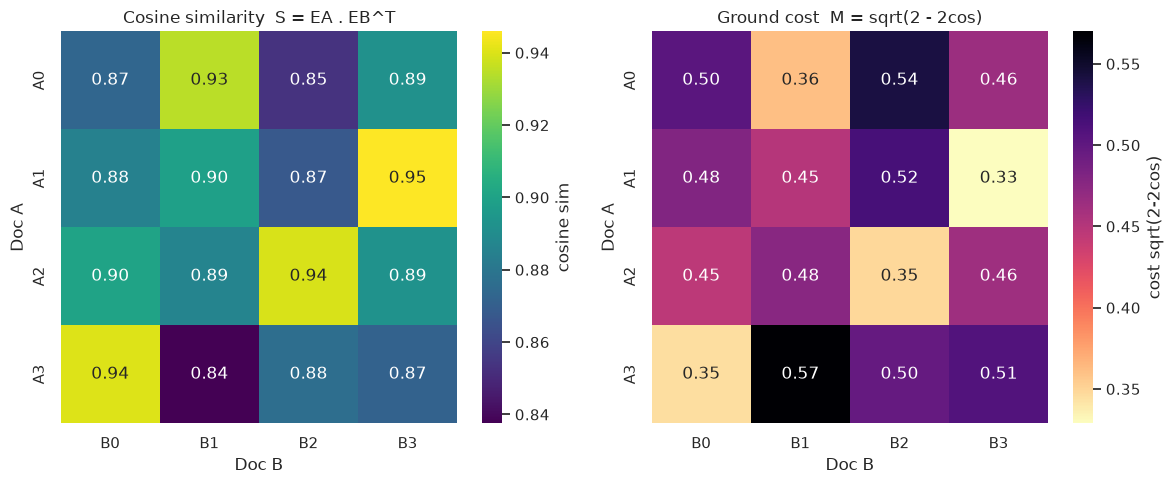

cost on the intended alignment cells (each is its row minimum):
  A0 -> B1: cost 0.362   (row min 0.362)
  A1 -> B3: cost 0.329   (row min 0.329)
  A2 -> B2: cost 0.349   (row min 0.349)
  A3 -> B0: cost 0.346   (row min 0.346)


In [7]:
C = cost_matrix(EA, EB)   # the ground cost M
S = EA @ EB.T             # cosine similarity (dot product of unit rows)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.heatmap(S, annot=True, fmt=".2f", cmap="viridis",
            xticklabels=LABELS_B, yticklabels=LABELS_A, ax=axes[0],
            cbar_kws={"label": "cosine sim"})
axes[0].set_title("Cosine similarity  S = EA . EB^T")
axes[0].set_xlabel("Doc B"); axes[0].set_ylabel("Doc A")
sns.heatmap(C, annot=True, fmt=".2f", cmap="magma_r",
            xticklabels=LABELS_B, yticklabels=LABELS_A, ax=axes[1],
            cbar_kws={"label": "cost sqrt(2-2cos)"})
axes[1].set_title("Ground cost  M = sqrt(2 - 2cos)")
axes[1].set_xlabel("Doc B"); axes[1].set_ylabel("Doc A")
fig.tight_layout()
plt.show()

intended = {0: 1, 1: 3, 2: 2, 3: 0}   # A -> B, the content correspondence
print("cost on the intended alignment cells (each is its row minimum):")
for i, j in intended.items():
    print(f"  A{i} -> B{j}: cost {C[i, j]:.3f}   (row min {C[i].min():.3f})")

## The marginals - how much mass each statement carries

Uniform nBOW weights give every statement equal mass $1/n$: each source statement must be fully sent and each target fully received. The masses sum to 1 on each side.

In [8]:
a = np.full(len(EA), 1 / len(EA))   # source marginal
b = np.full(len(EB), 1 / len(EB))   # target marginal
print("a (source marginal):", a, " sum =", a.sum())
print("b (target marginal):", b, " sum =", b.sum())

a (source marginal): [0.25 0.25 0.25 0.25]  sum = 1.0
b (target marginal): [0.25 0.25 0.25 0.25]  sum = 1.0


## The optimisation - the transport LP

Finding the cheapest way to move A's mass onto B is a linear program. POT solves it exactly with the network simplex (`ot.emd`), not the entropic / Sinkhorn approximation - there is no regularisation $\varepsilon$, and the result is deterministic.

$$T^\star=\arg\min_{T\ge 0}\ \langle T, M\rangle\quad\text{s.t.}\quad T\mathbf{1}=a,\ \ T^\top\mathbf{1}=b,\qquad \mathrm{SMD}=\langle T^\star, M\rangle$$

The optimum is sparse: at most $n_A + n_B - 1$ of the $n_A \times n_B$ cells are nonzero.

## Solving it - the transport plan T

Solve the LP and read the coupling. Most cells are zero; the few nonzero cells are the statement-to-statement flow. The mass concentrates on the intended paraphrase-and-reorder alignment - the optimisation discovers the correspondence despite B being reordered.

transport plan T (rows = A, cols = B):
[[0.   0.25 0.   0.  ]
 [0.   0.   0.   0.25]
 [0.   0.   0.25 0.  ]
 [0.25 0.   0.   0.  ]]

nonzero cells: 4   |   sparsity bound nA + nB - 1 = 7


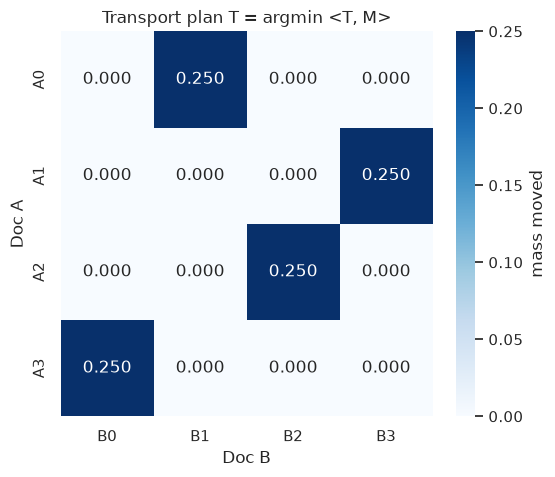

In [9]:
T = transport_plan(EA, EB)
print("transport plan T (rows = A, cols = B):")
print(np.round(T, 3))
nnz = int((T > 1e-12).sum())
print(f"\nnonzero cells: {nnz}   |   sparsity bound nA + nB - 1 = {len(EA) + len(EB) - 1}")

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(T, annot=True, fmt=".3f", cmap="Blues",
            xticklabels=LABELS_B, yticklabels=LABELS_A, ax=ax,
            cbar_kws={"label": "mass moved"})
ax.set_title("Transport plan T = argmin <T, M>")
ax.set_xlabel("Doc B"); ax.set_ylabel("Doc A")
plt.show()

## The distance = <T, M>

The SMD is the total cost of the optimal plan: the elementwise product of plan and cost, summed. Three routes give the same number - the manual sum, the `smd` helper, and `ot.emd2`. The contribution heatmap shows that only the few nonzero plan cells add to the distance.

(T * C).sum()    = 0.346191660
smd(EA, EB)      = 0.346191660
ot.emd2(a, b, C) = 0.346191660

SMD = 0.3462, closeness = 0.7552


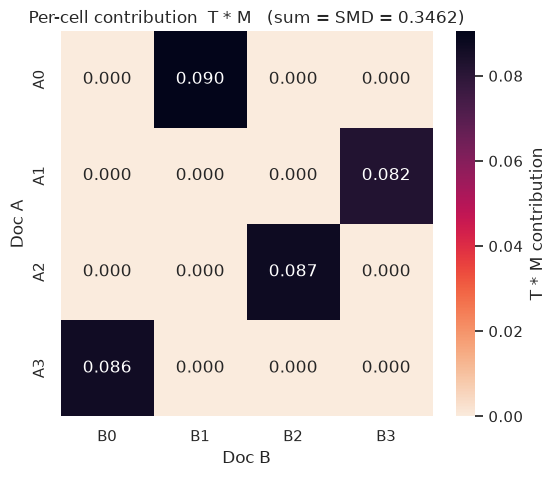

In [10]:
d = smd(EA, EB)
manual = float((T * C).sum())
via_emd2 = float(ot.emd2(a, b, C))
assert abs(manual - d) < 1e-9 and abs(via_emd2 - d) < 1e-9
print(f"(T * C).sum()    = {manual:.9f}")
print(f"smd(EA, EB)      = {d:.9f}")
print(f"ot.emd2(a, b, C) = {via_emd2:.9f}")
print(f"\nSMD = {d:.4f}, closeness = {closeness(d):.4f}")

contrib = T * C   # per-cell contribution; sums to SMD
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(contrib, annot=True, fmt=".3f", cmap="rocket_r",
            xticklabels=LABELS_B, yticklabels=LABELS_A, ax=ax,
            cbar_kws={"label": "T * M contribution"})
ax.set_title(f"Per-cell contribution  T * M   (sum = SMD = {d:.4f})")
ax.set_xlabel("Doc B"); ax.set_ylabel("Doc A")
plt.show()

## Reading the plan - which statement moved where

For each A-statement, the column carrying the most mass is its transported target. This recovered alignment is the document-distance analogue of a word-to-word WMD flow - the explainability the distance gives for free.

In [11]:
def trunc(s, n=40):
    return s if len(s) <= n else s[: n - 1] + "..."

rows = []
for i in range(len(EA)):
    j = int(T[i].argmax())
    rows.append({
        "A idx": f"A{i}", "A statement": trunc(DOC_A[i]),
        "-> B idx": f"B{j}", "B statement": trunc(DOC_B[j]),
        "mass": round(float(T[i].max()), 3), "cost": round(float(C[i, j]), 3),
    })
align_df = pd.DataFrame(rows)

align_tbl = Table(title="Recovered statement alignment A -> B")
for col in align_df.columns:
    align_tbl.add_column(col)
for _, r in align_df.iterrows():
    align_tbl.add_row(*[str(v) for v in r.values])
console.print(align_tbl)
align_df

                                       Recovered statement alignment A -> B                                        
┏━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━┳━━━━━━━┓
┃ A idx ┃ A statement                           ┃ -> B idx ┃ B statement                           ┃ mass ┃ cost  ┃
┡━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━╇━━━━━━━┩
│ A0    │ A cat rested on the warm windowsill.  │ B1       │ A feline lay on the sunlit ledge.     │ 0.25 │ 0.362 │
│ A1    │ It watched sparrows flutter in the    │ B3       │ It observed small birds out in the    │ 0.25 │ 0.329 │
│       │ gard...                               │          │ yard.                                 │      │       │
│ A2    │ After an hour the cat drifted off to  │ B2       │ An hour later it fell asleep.         │ 0.25 │ 0.349 │
│       │ sl...                                 │          │                                       │      │       │
│ A3    │ The whole house stayed quiet all      │ B0       │ The home remained silent through the  │ 0.25 │ 0.346 │
│       │ aftern...                             │          │ af...                                 │      │       │
└───────┴───────────────────────────────────────┴──────────┴───────────────────────────────────────┴──────┴───────┘

,A idx,A statement,-> B idx,B statement,mass,cost
0,A0,A cat rested on the warm windowsill.,B1,A feline lay on the sunlit ledge.,0.25,0.362
1,A1,It watched sparrows flutter in the gard...,B3,It observed small birds out in the yard.,0.25,0.329
2,A2,After an hour the cat drifted off to sl...,B2,An hour later it fell asleep.,0.25,0.349
3,A3,The whole house stayed quiet all aftern...,B0,The home remained silent through the af...,0.25,0.346


## Lower bounds - WCD <= RWMD <= SMD

Two cheap bounds bracket the full solve. The Word Centroid Distance (WCD) is the distance between the mean-pooled clouds - one move, the loosest bound. The Relaxed WMD (RWMD) drops one marginal constraint, letting every statement go to its nearest target - tighter. SMD is the exact LP optimum. Production code uses the bounds to prune candidate pairs cheaply before paying for the full solve.

WCD  = 0.1732
RWMD = 0.3462
SMD  = 0.3462


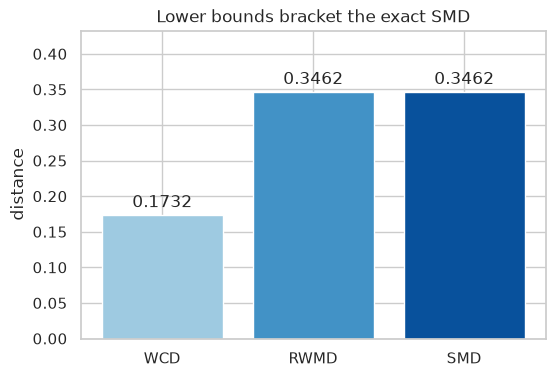

In [12]:
v_wcd = wcd(EA, EB)
v_rwmd = rwmd(EA, EB)
v_smd = smd(EA, EB)
assert v_wcd <= v_rwmd <= v_smd + 1e-9, "lower-bound chain WCD <= RWMD <= SMD must hold"
print(f"WCD  = {v_wcd:.4f}")
print(f"RWMD = {v_rwmd:.4f}")
print(f"SMD  = {v_smd:.4f}")

fig, ax = plt.subplots(figsize=(6, 4))
names = ["WCD", "RWMD", "SMD"]; vals = [v_wcd, v_rwmd, v_smd]
bars = ax.bar(names, vals, color=["#9ecae1", "#4292c6", "#08519c"])
ax.bar_label(bars, fmt="%.4f", padding=3)
ax.set_ylabel("distance"); ax.set_title("Lower bounds bracket the exact SMD")
ax.set_ylim(0, max(vals) * 1.25)
plt.show()

## Order-invariance - and where structure goes next

Permuting B's statements does not change the SMD: optimal transport matches on content and is blind to statement order.

In [13]:
perm = np.random.permutation(len(EB))
EB_shuf = EB[perm]
d_orig = smd(EA, EB)
d_shuf = smd(EA, EB_shuf)
print("permutation of B:", perm)
print(f"SMD(EA, EB)      = {d_orig:.6f}")
print(f"SMD(EA, EB_shuf) = {d_shuf:.6f}")
print("unchanged:", bool(np.isclose(d_orig, d_shuf)))

permutation of B: [2 3 1 0]
SMD(EA, EB)      = 0.346192
SMD(EA, EB_shuf) = 0.346192
unchanged: True


Because SMD is order-invariant it says nothing about arrangement - two documents with the same statements in any order score identically. To measure arrangement, the project adds a separate position-augmented Wasserstein channel (E08-H44), blended with this semantic SMD. See `docs/solution/wmd-structure-distance-sota.md` for the design and `notebooks/12-kj-structure-distance-e2e.ipynb` for the end-to-end showcase. That machinery is out of scope here.

## Conclusion

The pipeline is short and fully visible: statements → L2-normalized mmBERT embeddings → the ground cost $M = \sqrt{2-2\cos}$ → uniform marginals → the exact transport plan $T$ from the network-simplex LP → the distance $\langle T, M\rangle$ → the recovered statement-to-statement alignment. Two things make it trustworthy. The cost is the chord distance, so it is a true metric and the OT distance inherits the metric property. And the transport plan is the built-in explanation of the number - you can always read which statement moved where, and at what cost.